In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [6]:
HOLDS_HUE_RANGES = [
	# Orange
	[0, 45],
	# Yellow
	[45, 65],
	# Green
	[65, 140],
	# Blue
	[210, 250],
	# Purple
	[250, 270],
	# Pink
	[290, 320]
]

In [7]:
def resize(img, desired_width = 600):
	(h, w) = img.shape[:2]
	aspect_ratio = h / w
	new_height = int(desired_width * aspect_ratio)
	return cv2.resize(img, (desired_width, new_height))

def quantize(img, k = 8):
	pixels = img.reshape((-1, 3))
	pixels = np.float32(pixels)

	criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

	_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

	centers = np.uint8(centers)

	quantized_image = centers[labels.flatten()]
	quantized_image = quantized_image.reshape(img.shape)

	return quantized_image

def hsl_to_hsv(hue, saturation, luminance):
	return np.array([hue / 2, (saturation / 100) * 255, (luminance / 100) * 255])

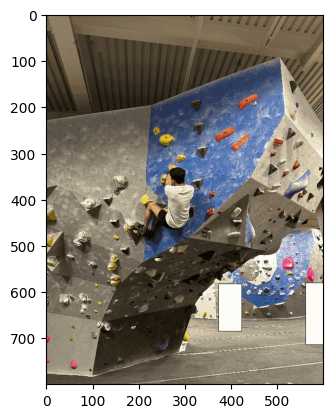

In [10]:
img = cv2.imread("./images/IMG_4705.png")
img = resize(img)
img = quantize(img, k = 100)

safe_for_human_eyes_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(safe_for_human_eyes_img)
plt.show()

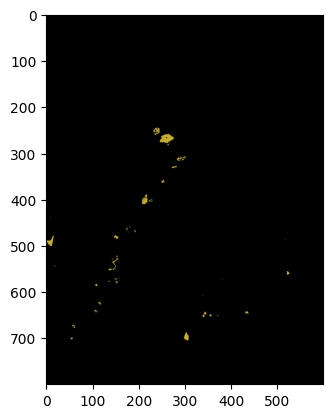

In [14]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# low and high for yellow range
[low, high] = HOLDS_HUE_RANGES[1]

mask = cv2.inRange(hsv, hsl_to_hsv(*[low, 50, 50]), hsl_to_hsv(*[high, 100, 100]))
result = cv2.bitwise_and(img, img, mask=mask)
result = quantize(result, k = 2)

safe_for_human_eyes_result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(safe_for_human_eyes_result)
plt.show()